<a href="https://colab.research.google.com/github/ayelefeleke/ASTU-Community-Financial-Inclusion-Hackathon/blob/main/ASTU_Community_Financial_Inclusion_Hackathon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Install Required Libraries

I'm install `catboost`, `scikit-learn`, `numpy`, `matplotlib`, and `seaborn` to ensure all necessary tools are available for data preprocessing, model training, and visualization.

In [ ]:
!pip install catboost scikit-learn numpy matplotlib seaborn

In [ ]:
import pandas as pd

# To Load the datasets
train_df = pd.read_csv('/content/Train.csv')
test_df = pd.read_csv('/content/Test.csv')
variable_definitions_df = pd.read_csv('/content/VariableDefinitions.csv')

print('Train DataFrame Head:')
display(train_df.head())
print('\nTrain DataFrame Info:')
train_df.info()

print('\nTest DataFrame Head:')
display(test_df.head())
print('\nTest DataFrame Info:')
test_df.info()

print('\nVariable Definitions:')
display(variable_definitions_df)

Train DataFrame Head:


,country,year,uniqueid,bank_account,location_type,cellphone_access,household_size,age_of_respondent,gender_of_respondent,relationship_with_head,marital_status,education_level,job_type
0,Kenya,2018,uniqueid_1,Yes,Rural,Yes,3,24,Female,Spouse,Married/Living together,Secondary education,Self employed
1,Kenya,2018,uniqueid_2,No,Rural,No,5,70,Female,Head of Household,Widowed,No formal education,Government Dependent
2,Kenya,2018,uniqueid_3,Yes,Urban,Yes,5,26,Male,Other relative,Single/Never Married,Vocational/Specialised training,Self employed
3,Kenya,2018,uniqueid_4,No,Rural,Yes,5,34,Female,Head of Household,Married/Living together,Primary education,Formally employed Private
4,Kenya,2018,uniqueid_5,No,Urban,No,8,26,Male,Child,Single/Never Married,Primary education,Informally employed



Train DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23524 entries, 0 to 23523
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   country                 23524 non-null  object
 1   year                    23524 non-null  int64 
 2   uniqueid                23524 non-null  object
 3   bank_account            23524 non-null  object
 4   location_type           23524 non-null  object
 5   cellphone_access        23524 non-null  object
 6   household_size          23524 non-null  int64 
 7   age_of_respondent       23524 non-null  int64 
 8   gender_of_respondent    23524 non-null  object
 9   relationship_with_head  23524 non-null  object
 10  marital_status          23524 non-null  object
 11  education_level         23524 non-null  object
 12  job_type                23524 non-null  object
dtypes: int64(3), object(10)
memory usage: 2.3+ MB

Test DataFrame Head:


,country,year,uniqueid,location_type,cellphone_access,household_size,age_of_respondent,gender_of_respondent,relationship_with_head,marital_status,education_level,job_type
0,Kenya,2018,uniqueid_6056,Urban,Yes,3,30,Male,Head of Household,Married/Living together,Secondary education,Formally employed Government
1,Kenya,2018,uniqueid_6060,Urban,Yes,7,51,Male,Head of Household,Married/Living together,Vocational/Specialised training,Formally employed Private
2,Kenya,2018,uniqueid_6065,Rural,No,3,77,Female,Parent,Married/Living together,No formal education,Remittance Dependent
3,Kenya,2018,uniqueid_6072,Rural,No,6,39,Female,Head of Household,Married/Living together,Primary education,Remittance Dependent
4,Kenya,2018,uniqueid_6073,Urban,No,3,16,Male,Child,Single/Never Married,Secondary education,Remittance Dependent



Test DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10086 entries, 0 to 10085
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   country                 10086 non-null  object
 1   year                    10086 non-null  int64 
 2   uniqueid                10086 non-null  object
 3   location_type           10086 non-null  object
 4   cellphone_access        10086 non-null  object
 5   household_size          10086 non-null  int64 
 6   age_of_respondent       10086 non-null  int64 
 7   gender_of_respondent    10086 non-null  object
 8   relationship_with_head  10086 non-null  object
 9   marital_status          10086 non-null  object
 10  education_level         10086 non-null  object
 11  job_type                10086 non-null  object
dtypes: int64(3), object(9)
memory usage: 945.7+ KB

Variable Definitions:


,Variable Definitions,Unnamed: 1
0,country,Country interviewee is in.
1,year,Year survey was done in.
2,uniqueid,Unique identifier for each interviewee
3,location_type,"Type of location: Rural, Urban"
4,cellphone_access,"If interviewee has access to a cellphone: Yes, No"
5,household_size,Number of people living in one house
6,age_of_respondent,The age of the interviewee
7,gender_of_respondent,"Gender of interviewee: Male, Female"
8,relationship_with_head,The interviewee’s relationship with the head o...
9,marital_status,The martial status of the interviewee: Married...


## Exploratory Data Analysis (EDA)
here is some EDA i will do
Let's start by understanding the distribution of our target variable, `bank_account`, and then explore other features.

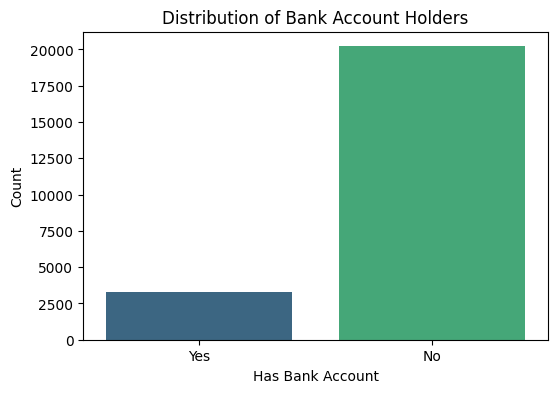

Value counts for bank_account:
bank_account
No     20212
Yes     3312
Name: count, dtype: int64

Percentage distribution:
bank_account
No     85.920762
Yes    14.079238
Name: proportion, dtype: float64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution of the target variable
plt.figure(figsize=(6, 4))
sns.countplot(x='bank_account', data=train_df, palette='viridis', hue='bank_account', legend=False)
plt.title('Distribution of Bank Account Holders')
plt.xlabel('Has Bank Account')
plt.ylabel('Count')
plt.show()

# Print value counts for better understanding
print('Value counts for bank_account:')
print(train_df['bank_account'].value_counts())
print('\nPercentage distribution:')
print(train_df['bank_account'].value_counts(normalize=True) * 100)


Now, let's explore the categorical features to see their unique values and their relationship with the target variable.

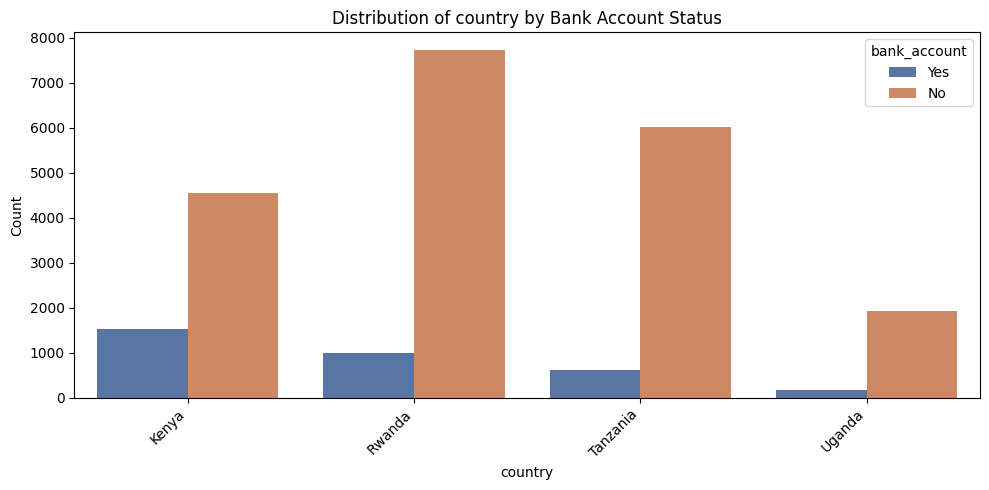

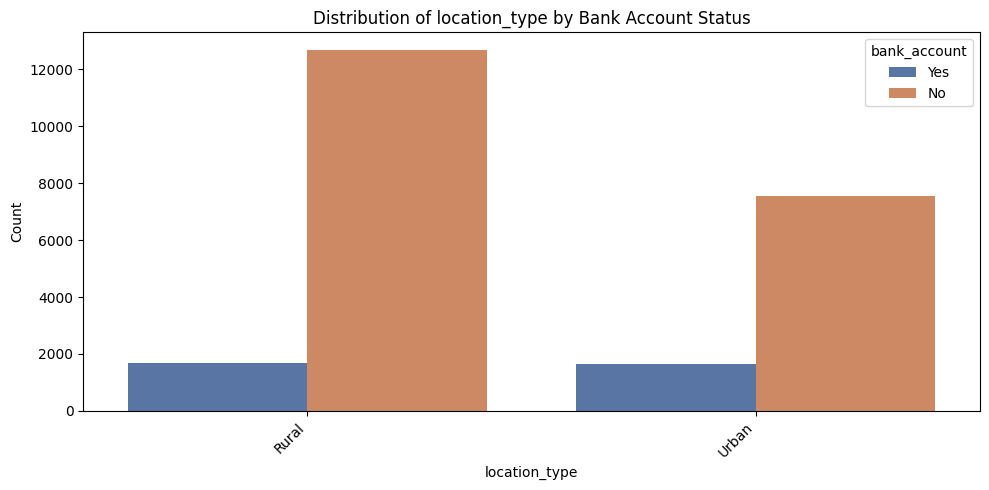

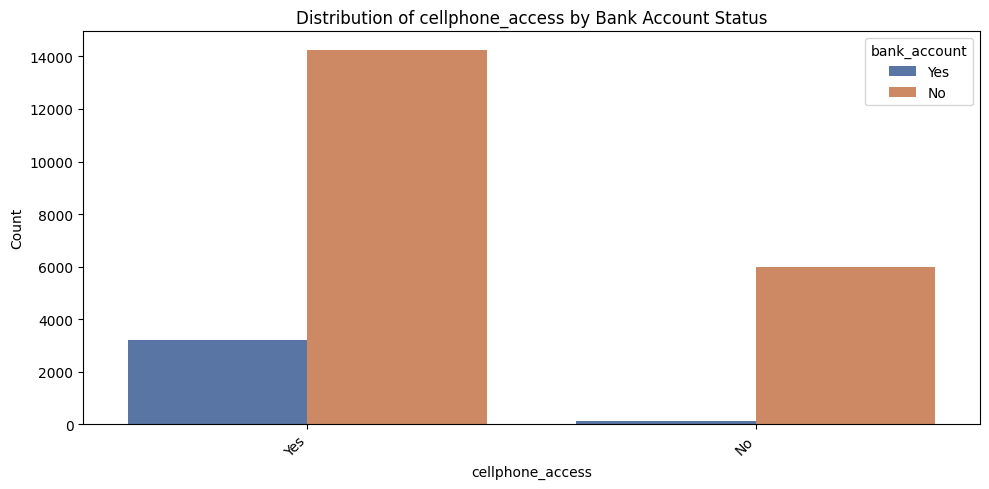

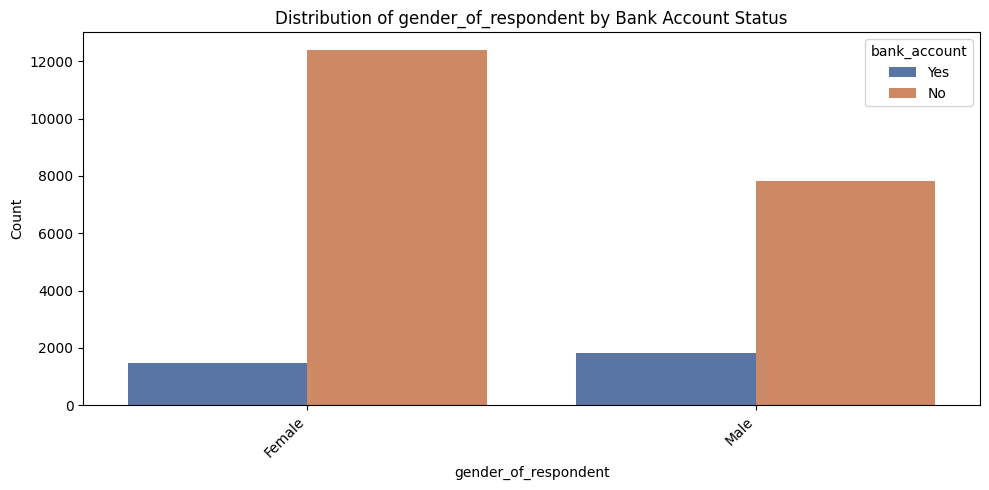

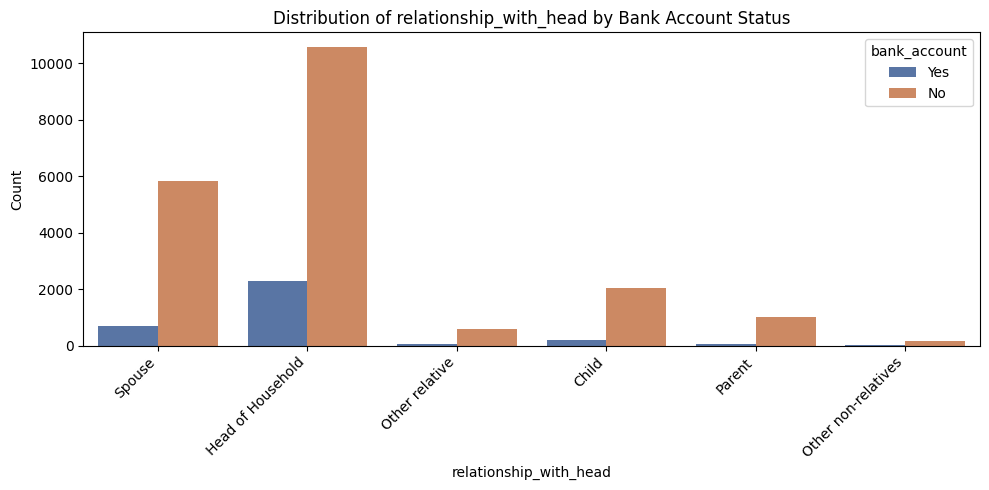

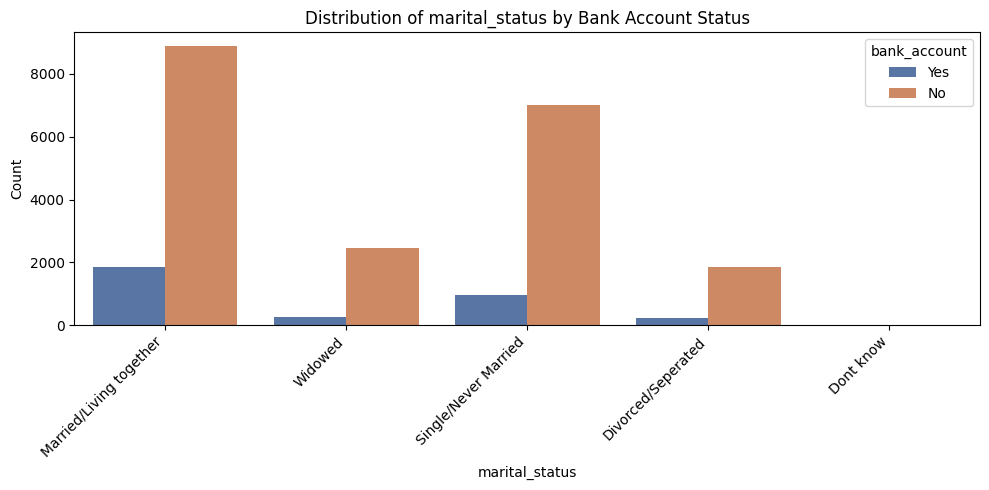

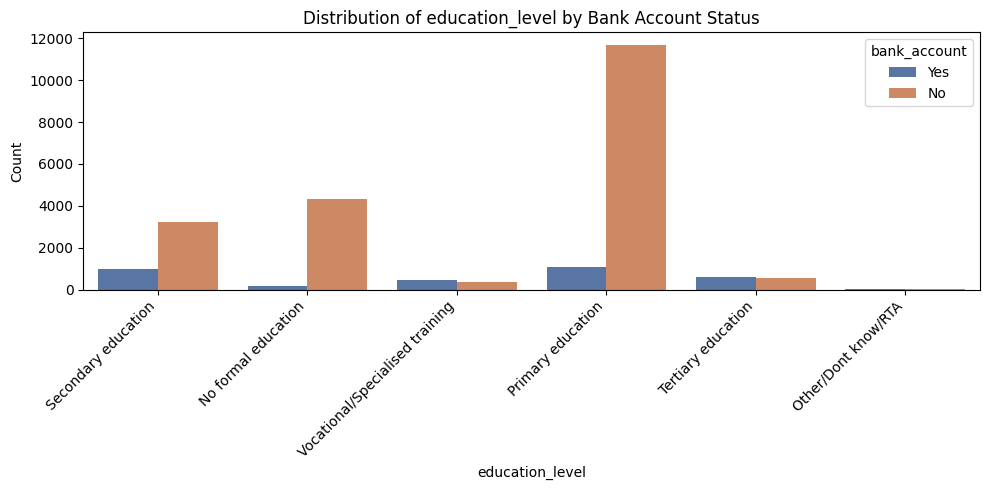

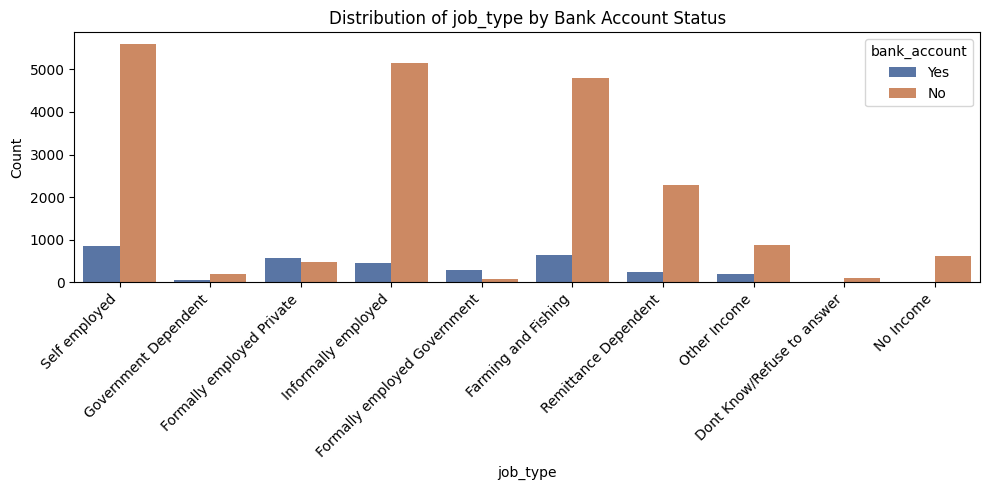

In [ ]:
categorical_cols = train_df.select_dtypes(include='object').columns.tolist()
# Remove 'uniqueid' and 'bank_account' from categorical columns for individual plotting
categorical_cols.remove('uniqueid')
categorical_cols.remove('bank_account')

for col in categorical_cols:
    plt.figure(figsize=(10, 5))
    sns.countplot(x=col, hue='bank_account', data=train_df, palette='deep')
    plt.title(f'Distribution of {col} by Bank Account Status')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

These plots give us a visual understanding of how different categorical features are distributed and how they relate to having a bank account. For instance, we can see differences across countries, location types, genders, and education levels.

Next, we should examine the numerical features: `household_size` and `age_of_respondent`. This will help us identify potential correlations or patterns.

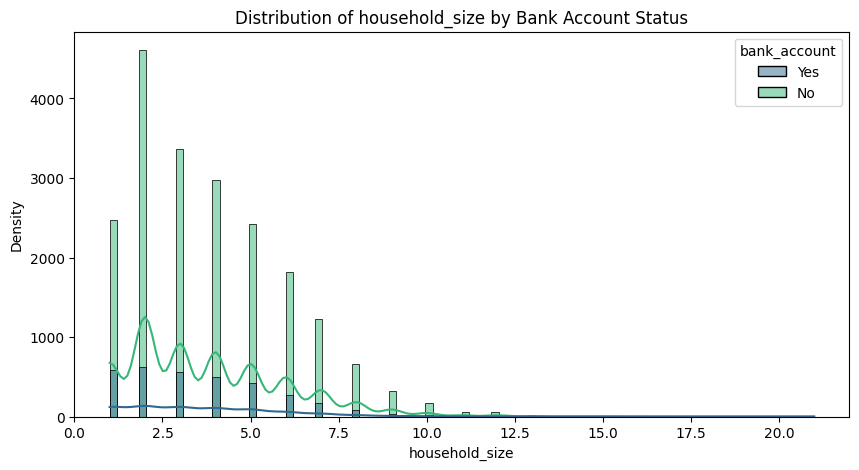

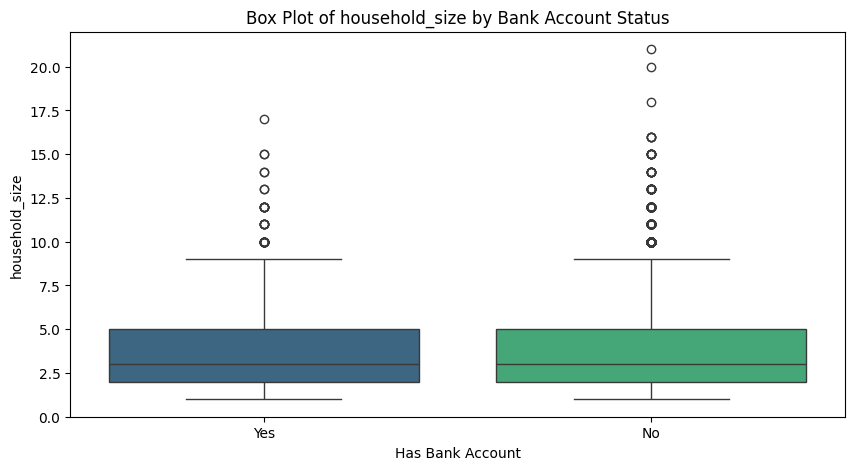

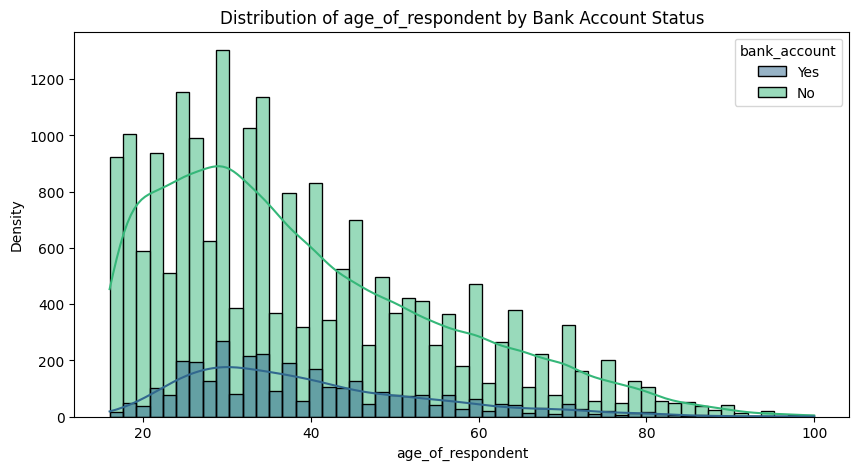

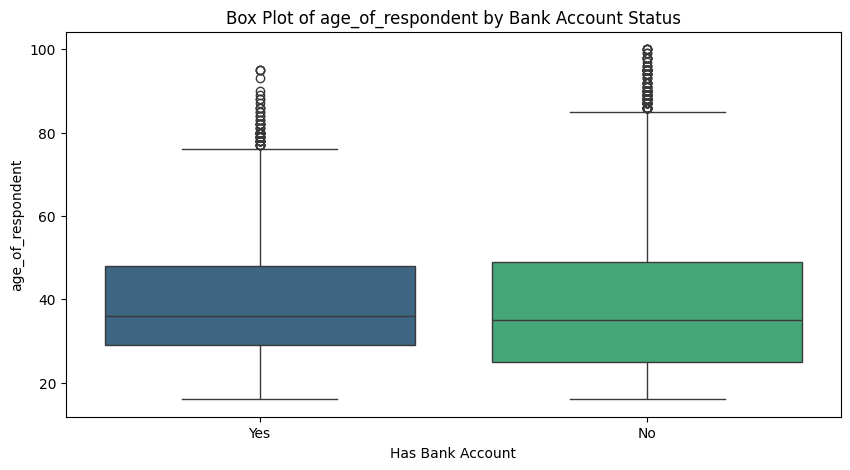

In [ ]:
numerical_cols = ['household_size', 'age_of_respondent']

for col in numerical_cols:
    plt.figure(figsize=(10, 5))
    sns.histplot(data=train_df, x=col, hue='bank_account', kde=True, palette='viridis')
    plt.title(f'Distribution of {col} by Bank Account Status')
    plt.xlabel(col)
    plt.ylabel('Density')
    plt.show()

    plt.figure(figsize=(10, 5))
    sns.boxplot(data=train_df, x='bank_account', y=col, palette='viridis', hue='bank_account', legend=False)
    plt.title(f'Box Plot of {col} by Bank Account Status')
    plt.xlabel('Has Bank Account')
    plt.ylabel(col)
    plt.show()

## Data Preprocessing

T

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

train_df_processed = train_df.copy()
test_df_processed = test_df.copy()


train_df_processed['bank_account'] = train_df_processed['bank_account'].map({'Yes': 1, 'No': 0})

# 2. Drop 'uniqueid' from both train and test datasets as it's an identifier
train_df_processed = train_df_processed.drop('uniqueid', axis=1)
test_df_processed = test_df_processed.drop('uniqueid', axis=1)


categorical_features_indices = []
categorical_features_names = []


features_for_catboost = [col for col in train_df_processed.columns if col != 'bank_account']

for i, col in enumerate(features_for_catboost):
    if train_df_processed[col].dtype == 'object':
        categorical_features_indices.append(i)
        categorical_features_names.append(col)

print(f"Categorical features identified: {categorical_features_names}")
print(f"Indices of categorical features: {categorical_features_indices}")

print('\nProcessed Train DataFrame Head:')
display(train_df_processed.head())
print('\nProcessed Test DataFrame Head:')
display(test_df_processed.head())

Categorical features identified: ['country', 'location_type', 'cellphone_access', 'gender_of_respondent', 'relationship_with_head', 'marital_status', 'education_level', 'job_type']
Indices of categorical features: [0, 2, 3, 6, 7, 8, 9, 10]

Processed Train DataFrame Head:


,country,year,bank_account,location_type,cellphone_access,household_size,age_of_respondent,gender_of_respondent,relationship_with_head,marital_status,education_level,job_type
0,Kenya,2018,1,Rural,Yes,3,24,Female,Spouse,Married/Living together,Secondary education,Self employed
1,Kenya,2018,0,Rural,No,5,70,Female,Head of Household,Widowed,No formal education,Government Dependent
2,Kenya,2018,1,Urban,Yes,5,26,Male,Other relative,Single/Never Married,Vocational/Specialised training,Self employed
3,Kenya,2018,0,Rural,Yes,5,34,Female,Head of Household,Married/Living together,Primary education,Formally employed Private
4,Kenya,2018,0,Urban,No,8,26,Male,Child,Single/Never Married,Primary education,Informally employed



Processed Test DataFrame Head:


,country,year,location_type,cellphone_access,household_size,age_of_respondent,gender_of_respondent,relationship_with_head,marital_status,education_level,job_type
0,Kenya,2018,Urban,Yes,3,30,Male,Head of Household,Married/Living together,Secondary education,Formally employed Government
1,Kenya,2018,Urban,Yes,7,51,Male,Head of Household,Married/Living together,Vocational/Specialised training,Formally employed Private
2,Kenya,2018,Rural,No,3,77,Female,Parent,Married/Living together,No formal education,Remittance Dependent
3,Kenya,2018,Rural,No,6,39,Female,Head of Household,Married/Living together,Primary education,Remittance Dependent
4,Kenya,2018,Urban,No,3,16,Male,Child,Single/Never Married,Secondary education,Remittance Dependent


## Data Preprocessing


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Make a copy to avoid modifying the original DataFrames directly
train_df_processed = train_df.copy()
test_df_processed = test_df.copy()

# 1. Encode the target variable 'bank_account'
# Convert 'Yes' to 1 and 'No' to 0
train_df_processed['bank_account'] = train_df_processed['bank_account'].map({'Yes': 1, 'No': 0})

# 2. Drop 'uniqueid' from both train and test datasets as it's an identifier
train_df_processed = train_df_processed.drop('uniqueid', axis=1)
test_df_processed = test_df_processed.drop('uniqueid', axis=1)

# 3. Identify categorical features for CatBoost
# CatBoost can handle object types directly, but it's good practice to list them
categorical_features_indices = []
categorical_features_names = []

for i, col in enumerate(train_df_processed.drop('bank_account', axis=1).columns):
    if train_df_processed[col].dtype == 'object':
        categorical_features_indices.append(i)
        categorical_features_names.append(col)

print(f"Categorical features identified: {categorical_features_names}")
print(f"Indices of categorical features: {categorical_features_indices}")

print('\nProcessed Train DataFrame Head:')
display(train_df_processed.head())
print('\nProcessed Test DataFrame Head:')
display(test_df_processed.head())

Categorical features identified: ['country', 'location_type', 'cellphone_access', 'gender_of_respondent', 'relationship_with_head', 'marital_status', 'education_level', 'job_type']
Indices of categorical features: [0, 2, 3, 6, 7, 8, 9, 10]

Processed Train DataFrame Head:


,country,year,bank_account,location_type,cellphone_access,household_size,age_of_respondent,gender_of_respondent,relationship_with_head,marital_status,education_level,job_type
0,Kenya,2018,1,Rural,Yes,3,24,Female,Spouse,Married/Living together,Secondary education,Self employed
1,Kenya,2018,0,Rural,No,5,70,Female,Head of Household,Widowed,No formal education,Government Dependent
2,Kenya,2018,1,Urban,Yes,5,26,Male,Other relative,Single/Never Married,Vocational/Specialised training,Self employed
3,Kenya,2018,0,Rural,Yes,5,34,Female,Head of Household,Married/Living together,Primary education,Formally employed Private
4,Kenya,2018,0,Urban,No,8,26,Male,Child,Single/Never Married,Primary education,Informally employed



Processed Test DataFrame Head:


,country,year,location_type,cellphone_access,household_size,age_of_respondent,gender_of_respondent,relationship_with_head,marital_status,education_level,job_type
0,Kenya,2018,Urban,Yes,3,30,Male,Head of Household,Married/Living together,Secondary education,Formally employed Government
1,Kenya,2018,Urban,Yes,7,51,Male,Head of Household,Married/Living together,Vocational/Specialised training,Formally employed Private
2,Kenya,2018,Rural,No,3,77,Female,Parent,Married/Living together,No formal education,Remittance Dependent
3,Kenya,2018,Rural,No,6,39,Female,Head of Household,Married/Living together,Primary education,Remittance Dependent
4,Kenya,2018,Urban,No,3,16,Male,Child,Single/Never Married,Secondary education,Remittance Dependent


## Model Training with CatBoost

I'll use CatBoost Classifier, as it's well-suited for tabular data and can handle categorical features directly, which aligns with our dataset. We'll split our data into features (X) and the target variable (y), then train the model.

In [ ]:
from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import mean_absolute_error
import numpy as np

X = train_df_processed.drop('bank_account', axis=1)
y = train_df_processed['bank_account']

# Convert column names to string for CatBoost compatibility if they are not already
X.columns = X.columns.astype(str)
test_df_processed.columns = test_df_processed.columns.astype(str)

cat_params = {
    'iterations': 1000,
    'learning_rate': 0.05,
    'depth': 8,
    'l2_leaf_reg': 3,
    'loss_function': 'Logloss',
    'eval_metric': 'AUC',
    'random_seed': 42,
    'verbose': 100,
    'early_stopping_rounds': 50
}

# Initialize CatBoost model
model = CatBoostClassifier(**cat_params)

print("\nTraining CatBoost Model...")

#
model.fit(
    X,
    y,
    cat_features=categorical_features_names,
)

print("\nCatBoost Model Training Complete!")


test_pred_proba = model.predict_proba(test_df_processed)[:, 1]


test_predictions = (test_pred_proba >= 0.5).astype(int)

print("\nPredictions made on the test set.")

submission_df = pd.DataFrame({
    'uniqueid': test_df['uniqueid'],
    'bank_account': test_predictions
})


submission_df['uniqueid'] = test_df['uniqueid'] + ' x ' + test_df['country']


submission_filename = 'catboost_submission.csv'
submission_df.to_csv(submission_filename, index=False)

print(f"Submission file '{submission_filename}' created successfully!")
print(submission_df.head())


Training CatBoost Model...
0:	total: 229ms	remaining: 3m 48s
100:	total: 11s	remaining: 1m 38s
200:	total: 15.8s	remaining: 1m 2s
300:	total: 21.8s	remaining: 50.5s
400:	total: 26.7s	remaining: 39.9s
500:	total: 33s	remaining: 32.9s
600:	total: 37.9s	remaining: 25.1s
700:	total: 45.4s	remaining: 19.4s
800:	total: 50.2s	remaining: 12.5s
900:	total: 1m 1s	remaining: 6.73s
999:	total: 1m 6s	remaining: 0us

CatBoost Model Training Complete!

Predictions made on the test set.
Submission file 'catboost_submission.csv' created successfully!
                uniqueid  bank_account
0  uniqueid_6056 x Kenya             1
1  uniqueid_6060 x Kenya             1
2  uniqueid_6065 x Kenya             0
3  uniqueid_6072 x Kenya             0
4  uniqueid_6073 x Kenya             0


# Here i'm also use StratifiedKFold

Instead of training once:

Data is split into 5 parts (folds)
Each fold becomes validation once
Model trains 5 different times

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import log_loss, mean_absolute_error, roc_auc_score
import numpy as np

# Number of folds for cross-validation
N_SPLITS = 5

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

# Lists to store predictions and model performance metrics
oof_preds = np.zeros((X.shape[0],))
test_preds_proba_list = []
model_auc_scores = []
model_mae_scores = []

print(f"\nStarting {N_SPLITS}-Fold Stratified Cross-Validation with updated parameters...")
print(f"CatBoost parameters being used: {cat_params}")

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    print(f"\n--- Fold {fold + 1}/{N_SPLITS} ---")

    X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
    X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]

    # Re-initialize model for each fold to ensure clean training
    fold_model = CatBoostClassifier(**cat_params)

    fold_model.fit(
        X_train,
        y_train,
        cat_features=categorical_features_names,
        eval_set=(X_val, y_val),
        early_stopping_rounds=cat_params['early_stopping_rounds'],
        verbose=False # Set to True for verbose output during fold training
    )

    # Out-of-fold predictions for validation set
    oof_preds[val_idx] = fold_model.predict_proba(X_val)[:, 1]

    # Predictions for the test set
    test_preds_proba_list.append(fold_model.predict_proba(test_df_processed)[:, 1])

    # Evaluate fold model
    fold_auc = roc_auc_score(y_val, oof_preds[val_idx])
    fold_mae = mean_absolute_error(y_val, (oof_preds[val_idx] >= 0.5).astype(int))

    model_auc_scores.append(fold_auc)
    model_mae_scores.append(fold_mae)

    print(f"Fold {fold + 1} - AUC: {fold_auc:.4f}, MAE: {fold_mae:.4f}")

print("\nCross-Validation Complete!")

# Aggregate OOF predictions and test predictions
final_oof_auc = roc_auc_score(y, oof_preds)
final_oof_mae = mean_absolute_error(y, (oof_preds >= 0.5).astype(int))

print(f"\nOverall OOF AUC: {final_oof_auc:.4f}")
print(f"Overall OOF MAE: {final_oof_mae:.4f}")
print(f"Average Fold AUC: {np.mean(model_auc_scores):.4f} +/- {np.std(model_auc_scores):.4f}")
print(f"Average Fold MAE: {np.mean(model_mae_scores):.4f} +/- {np.std(model_mae_scores):.4f}")

# Average predictions from all folds for the test set
final_test_pred_proba = np.mean(test_preds_proba_list, axis=0)
final_test_predictions = (final_test_pred_proba >= 0.5).astype(int)

print("\nFinal predictions on the test set generated via cross-validation.")

# Create a new submission DataFrame with cross-validated predictions
submission_df_cv = pd.DataFrame({
    'uniqueid': test_df['uniqueid'] + ' x ' + test_df['country'],
    'bank_account': final_test_predictions
})

submission_filename_cv = 'catboost_submission_cv.csv'
submission_df_cv.to_csv(submission_filename_cv, index=False)

print(f"Submission file '{submission_filename_cv}' created successfully!")
display(submission_df_cv.head())


Starting 5-Fold Stratified Cross-Validation with updated parameters...
CatBoost parameters being used: {'iterations': 1000, 'learning_rate': 0.05, 'depth': 8, 'l2_leaf_reg': 3, 'loss_function': 'Logloss', 'eval_metric': 'AUC', 'random_seed': 42, 'verbose': 100, 'early_stopping_rounds': 50}

--- Fold 1/5 ---
Fold 1 - AUC: 0.8665, MAE: 0.1141

--- Fold 2/5 ---
Fold 2 - AUC: 0.8642, MAE: 0.1112

--- Fold 3/5 ---
Fold 3 - AUC: 0.8733, MAE: 0.1080

--- Fold 4/5 ---
Fold 4 - AUC: 0.8664, MAE: 0.1135

--- Fold 5/5 ---
Fold 5 - AUC: 0.8631, MAE: 0.1131

Cross-Validation Complete!

Overall OOF AUC: 0.8663
Overall OOF MAE: 0.1120
Average Fold AUC: 0.8667 +/- 0.0036
Average Fold MAE: 0.1120 +/- 0.0022

Final predictions on the test set generated via cross-validation.
Submission file 'catboost_submission_cv.csv' created successfully!


,uniqueid,bank_account
0,uniqueid_6056 x Kenya,1
1,uniqueid_6060 x Kenya,1
2,uniqueid_6065 x Kenya,0
3,uniqueid_6072 x Kenya,0
4,uniqueid_6073 x Kenya,0


In [ ]:
from google.colab import files
files.download("catboost_submission_cv.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>